# Libraries

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark import SparkContext
from pyspark.mllib.clustering import KMeans
from matplotlib.colors import LinearSegmentedColormap

## Possible Rarities and its order

In [87]:
#Rarity Order for sorting
#Higher value means rarer card
rarityOrder = {
    "Common": 10,
    "Uncommon": 20,
    "Rare": 30,                         # Regular
    "Classic Collection": 31,
    "Rare Holo": 40,                    # Holofoil
    "Double Rare": 50,                  # EX
    "Ultra Rare": 60,                   # Unique card classification
    "Rare Ultra": 60,                   # Unique card classification
    "Rare Holo Star": 61,
    "Rare Prime": 61,
    "Rare Holo LV.X": 61,
    "Rare Holo EX": 61,
    "Rare Holo GX": 61,
    "LEGEND": 61,
    "Rare BREAK": 61,
    "Amazing Rare": 61,
    "Rare Prism Star": 61,
    "Rare ACE": 61,
    "ACE SPEC Rare": 61,
    "Radiant Rare": 62,
    "Rare Holo V": 63,
    "Rare Holo VSTAR": 64,
    "Rare Holo VMAX": 65,
    "Trainer Gallery Rare Holo": 66,
    "Rare Secret": 70,                  # Out of numbers
    "Rare Shining": 71,                 # Shiny Pokemon
    "Shiny Rare": 72,                   # Shiny Pokemon
    "Rare Shiny": 72,                   # Shiny Pokemon
    "Rare Shiny GX": 73,                # Shiny Pokemon
    "Shiny Ultra Rare": 73,             # Shiny Pokemon
    "Rare Rainbow": 74,
    "Illustration Rare": 75,            # Full-Art
    "Special Illustration Rare": 76,    # Full-Art
    "Hyper Rare": 80,                   # Gold Cards
    "Promo": 90                         # Event Cards
}

replace_dict = {1:1, 2:2, 3:3, 5:4, 7:5, 10:6, 21:7, 23:8, 25:9, 31:10}

#List of grade order
#Number has no meaning other than numeric encoding.
gradeOrder = {
    'holo-nearmint': 1,
    'holo-good': 2,
    'holo-played': 3,
    'holo-used' : 4, 
    'holo-poor': 5,
    'reverse-nearmint': 6,
    'reverse-good': 7,
    'reverse-played': 8,
    'reverse-used': 9,
    'reverse-poor': 10,
    'normal-nearmint': 11,
    'normal-good': 12,
    'normal-played': 13,
    'normal-used': 14,
    'normal-poor': 15
}

# Dataframe

In [88]:
#Read data
df = pd.read_csv('merged_pokemon_data.csv')

#Process Data
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df['Month'] = df['Month'].dt.strftime('%Y-%m')
df = df.sort_values('Month')

#Create the Average column to cover monthly prices
df['Average'] = pd.to_numeric(df['Average'], errors='coerce')

#Sort the unique rarities in the DataFrame using rarityOrder
sorted_rarities = sorted(df['Rarity'].dropna().unique(), key=lambda r: rarityOrder.get(r, float('inf')), reverse=True)
sorted_grades = sorted(df['Grade'].dropna().unique(), key=lambda r: gradeOrder.get(r, float('inf')), reverse=False)

In [89]:
#Observe the most expensive cards in our data set. 
#Notice multiple grade entries or month entries of the same card 
print(df.sort_values(by='Average', ascending=False))

      Set ID  Number          Name        Rarity            Grade    Month  \
34444  swsh5     155   Tyranitar V    Rare Ultra    holo-nearmint  2024-05   
34445  swsh5     155   Tyranitar V    Rare Ultra    holo-nearmint  2024-06   
28024  swsh4     188  Pikachu VMAX  Rare Rainbow        holo-good  2023-03   
34439  swsh5     155   Tyranitar V    Rare Ultra        holo-good  2024-05   
28023  swsh4     188  Pikachu VMAX  Rare Rainbow        holo-good  2023-02   
...      ...     ...           ...           ...              ...      ...   
22448  swsh3      58     Electrike        Common      normal-good  2023-07   
27039  swsh4     159  Rocky Helmet      Uncommon    normal-played  2024-08   
25396  swsh4     123     Ferroseed        Common      normal-good  2023-02   
26688  swsh4     151   Drone Rotom      Uncommon  normal-nearmint  2024-05   
3022   swsh1     165           Hop      Uncommon    normal-played  2024-08   

        Average  
34444  18767.00  
34445  17478.89  
28024  16

# Heatmaps

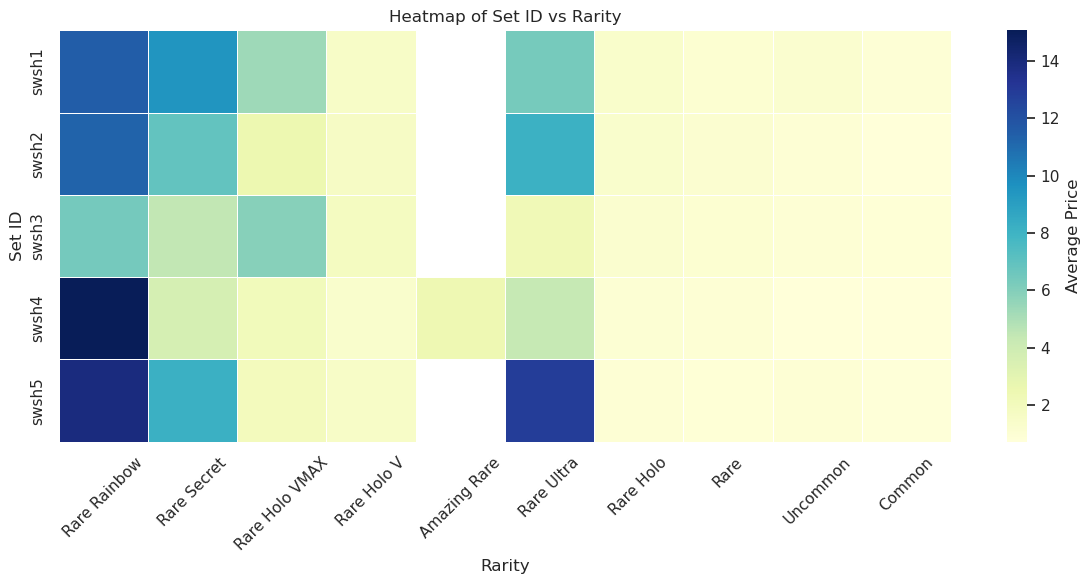

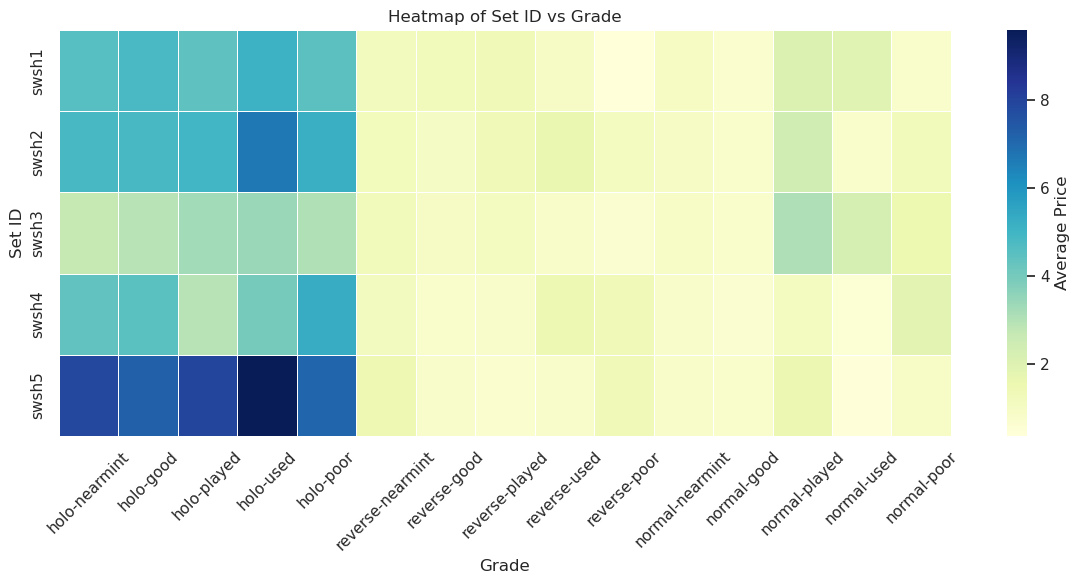

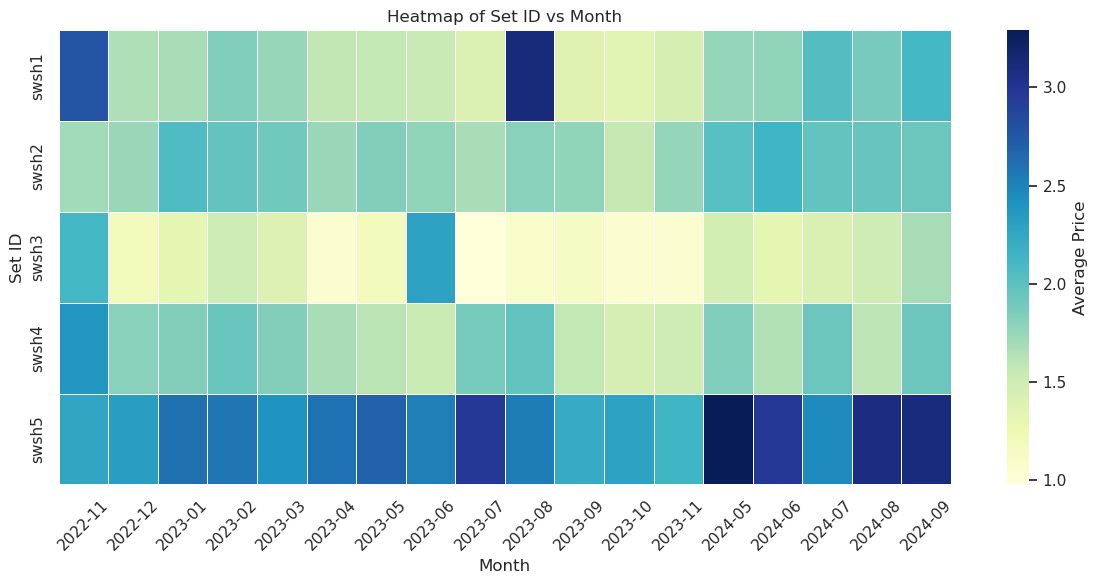

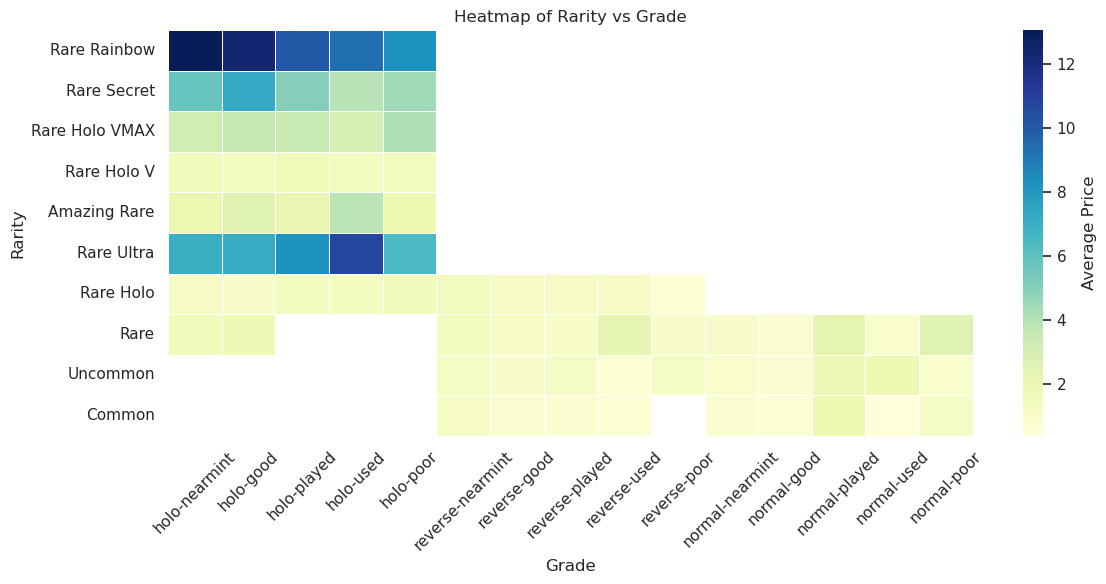

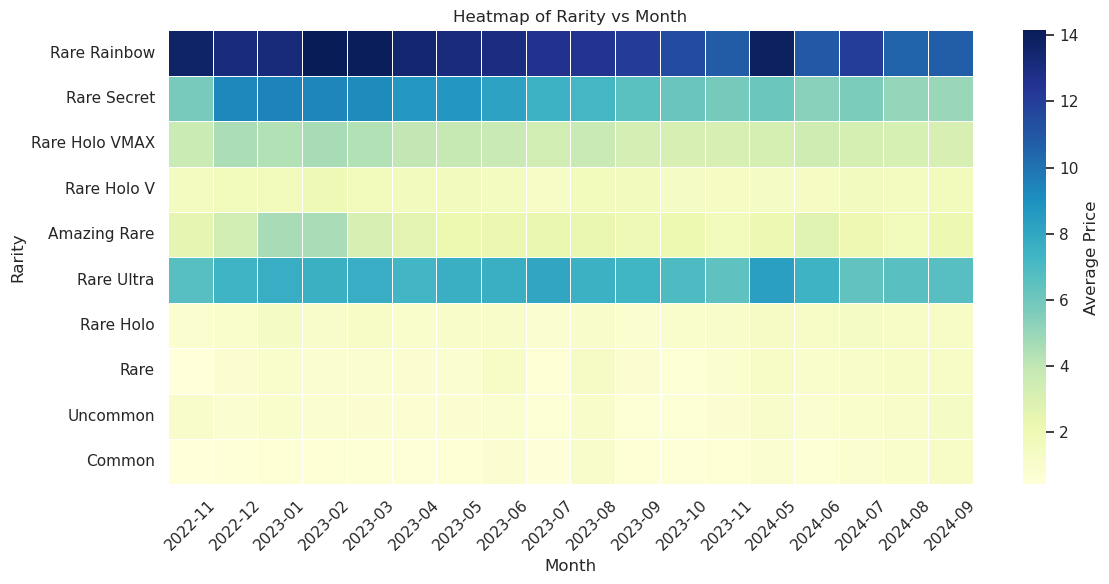

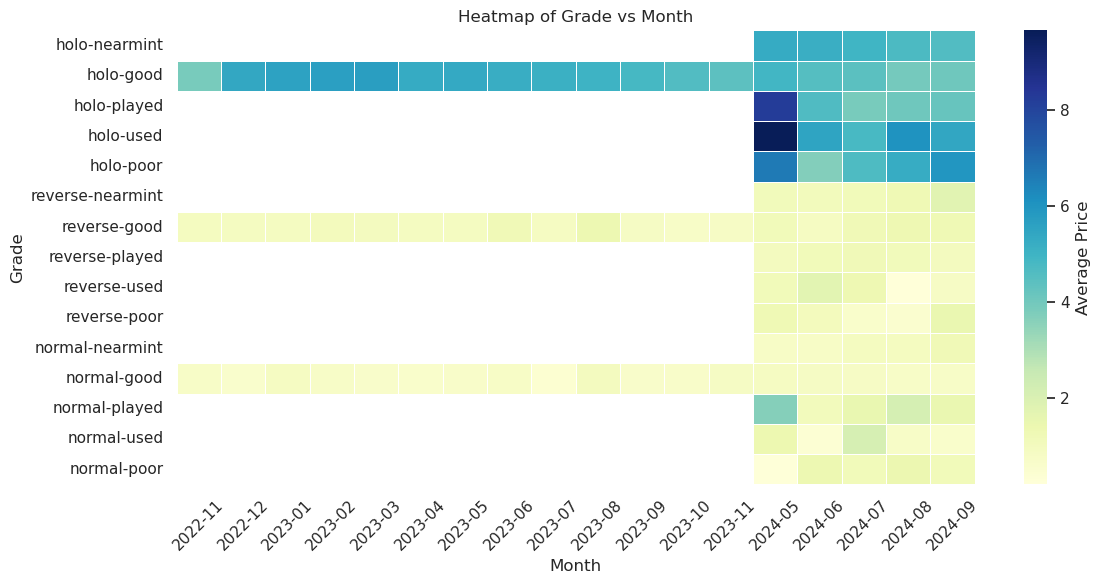

In [90]:
#List of heatmap pairs
heatmap_combos = [
    ('Set ID', 'Rarity'),
    ('Set ID', 'Grade'),
    ('Set ID', 'Month'),
    ('Rarity', 'Grade'),
    ('Rarity', 'Month'),
    ('Grade', 'Month'),
]

for row_attr, col_attr in heatmap_combos:
    pivot_table = df.pivot_table(index=row_attr, columns=col_attr, values='Average', aggfunc='mean')
    pivot_table = pivot_table.div(100).round(2)

    #Sort based on Rarity if it's in the rows or columns
    if row_attr == 'Rarity':
        pivot_table = pivot_table.loc[sorted_rarities]
    if col_attr == 'Rarity':
        pivot_table = pivot_table[sorted_rarities]

    #Sort based on Grade if it's in the rows or columns
    if row_attr == 'Grade':
        pivot_table = pivot_table.loc[sorted_grades]
    if col_attr == 'Grade':
        pivot_table = pivot_table[sorted_grades]

    #Plot
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=False, cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Average Price'})
    plt.title(f'Heatmap of {row_attr} vs {col_attr}')
    plt.ylabel(row_attr)
    plt.xlabel(col_attr)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Scatterplots

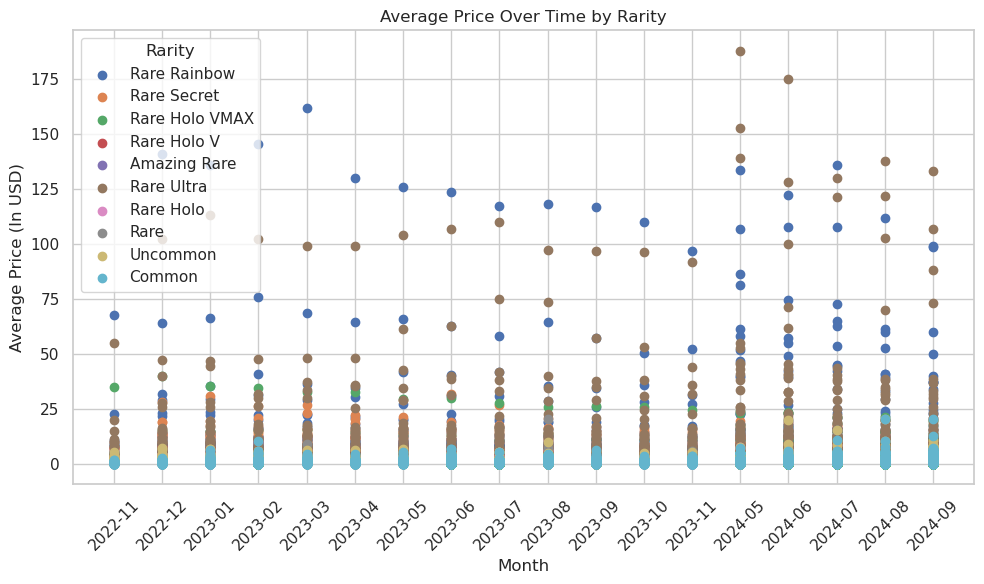

In [91]:
#Process Data
plt.figure(figsize=(10, 6))
dfs_by_rarity = []
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]
    dfs_by_rarity.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=rarity, marker='o')

#Set graph title and labels
plt.title('Average Price Over Time by Rarity')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Rarity')
plt.grid(True)
plt.tight_layout()

plt.show()


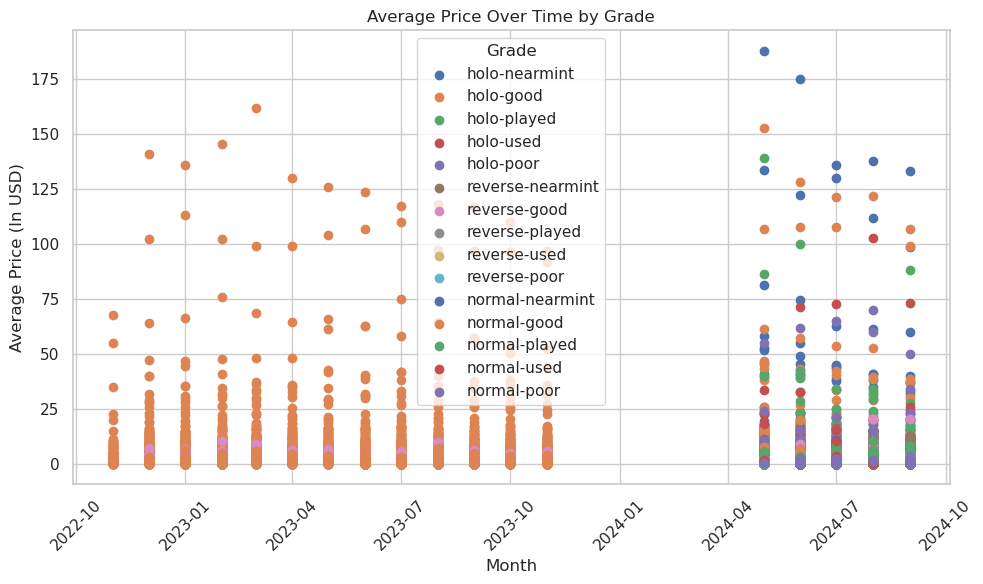

In [92]:
#Load and prepare data
df_sub = pd.read_csv('merged_pokemon_data.csv')
df_sub['Month'] = pd.to_datetime(df_sub['Month'], errors='coerce')
df_sub = df_sub.sort_values('Month')

#Process Data
plt.figure(figsize=(10, 6))
dfs_by_grade = []

for grade in sorted_grades:
    subset = df_sub[df_sub['Grade'] == grade]
    dfs_by_grade.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=grade, marker='o')

#Plot
plt.title('Average Price Over Time by Grade')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Grade')
plt.grid(True)
plt.tight_layout()

#Format x-axis as "YYYY-MM"
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.show()


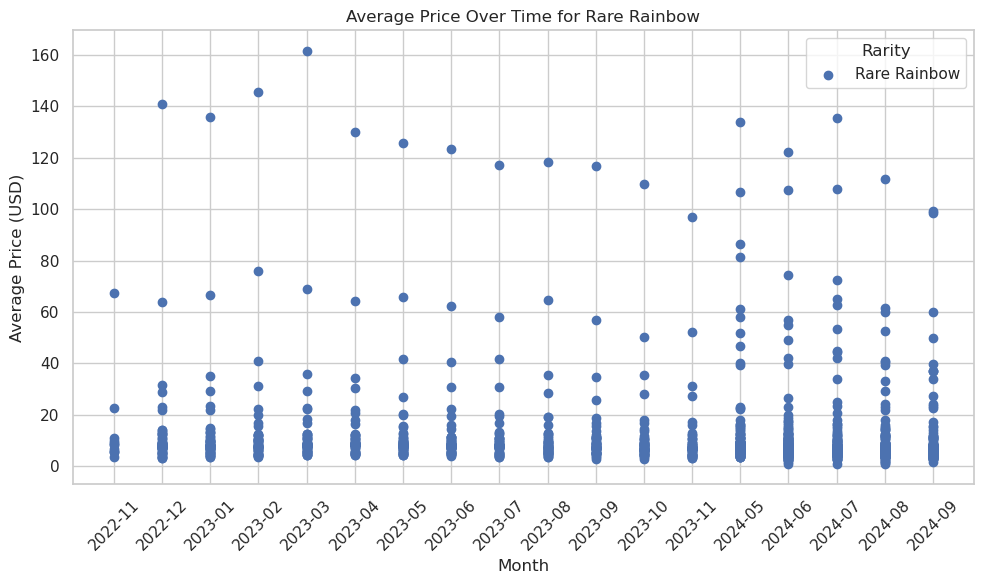

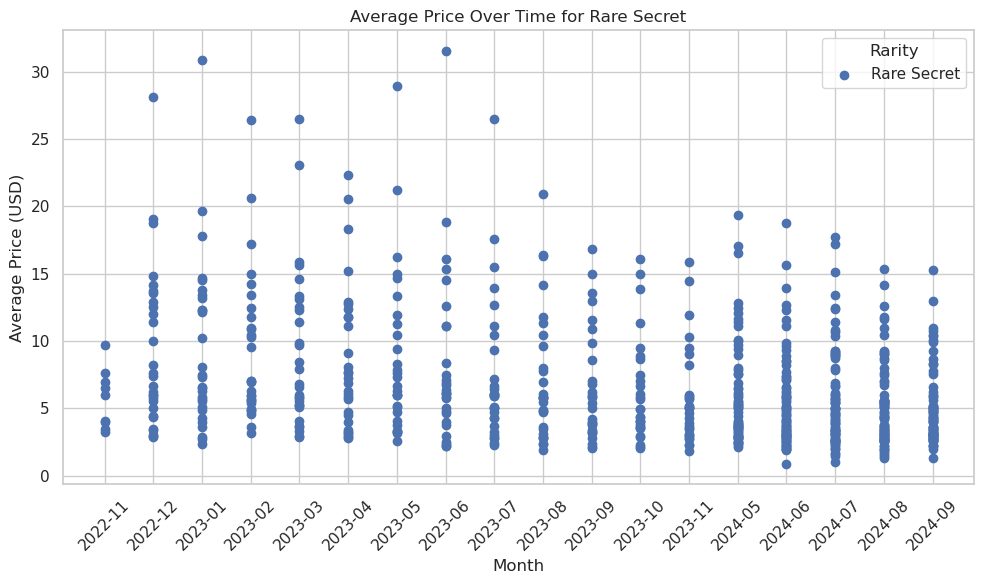

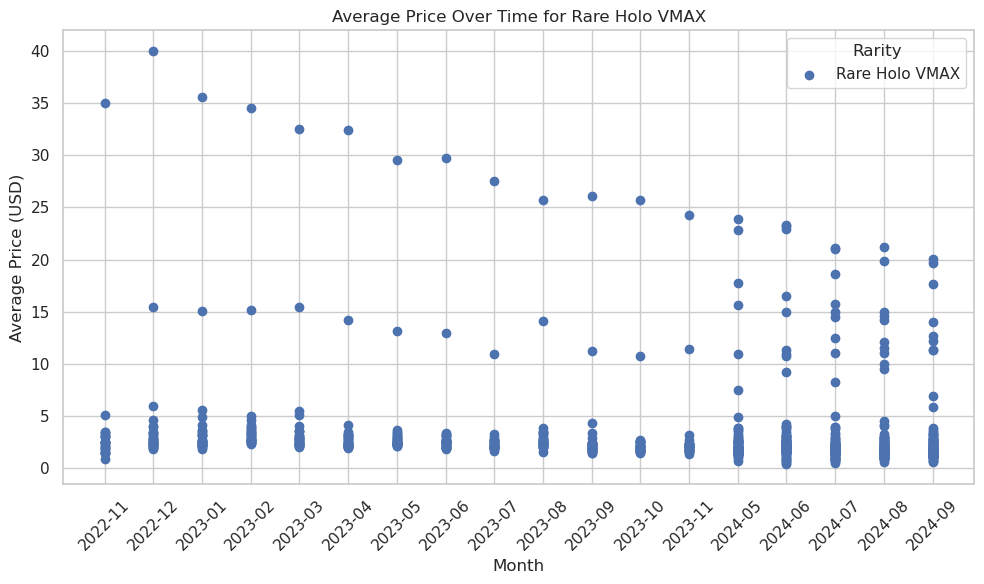

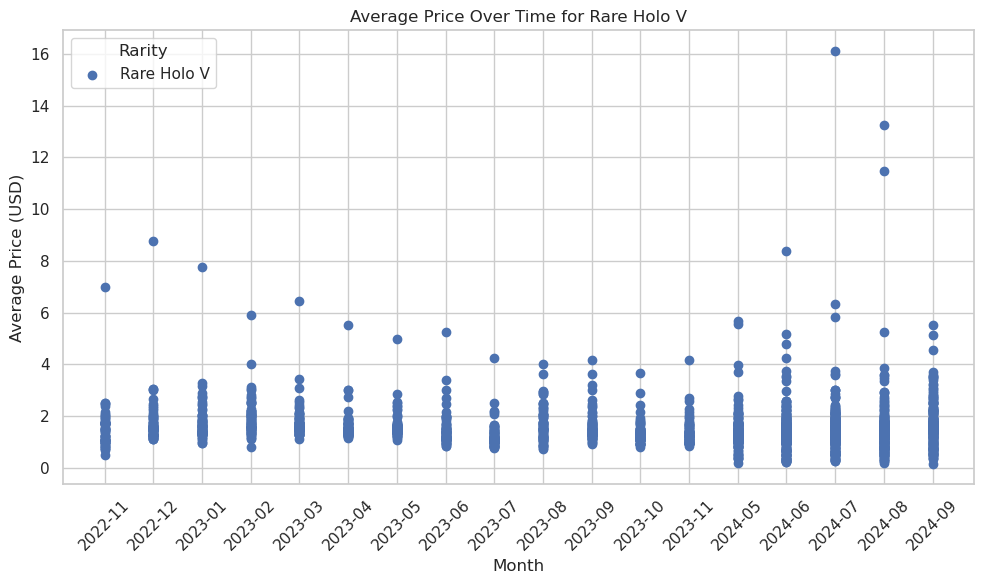

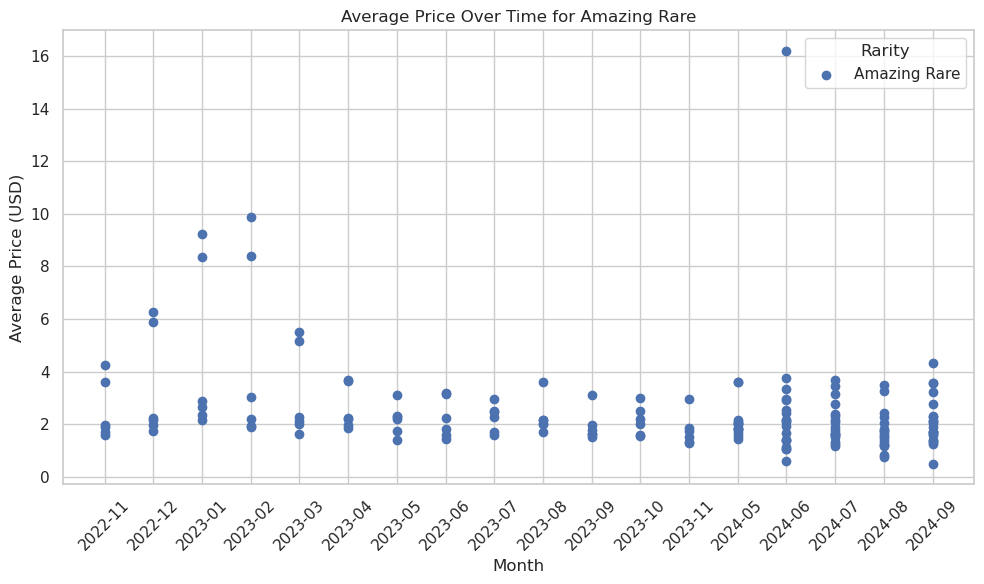

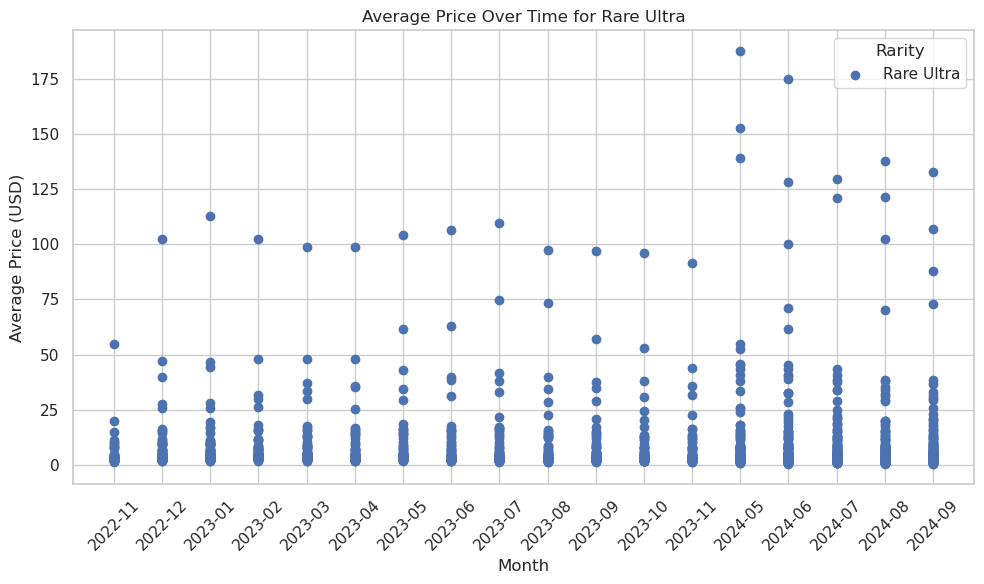

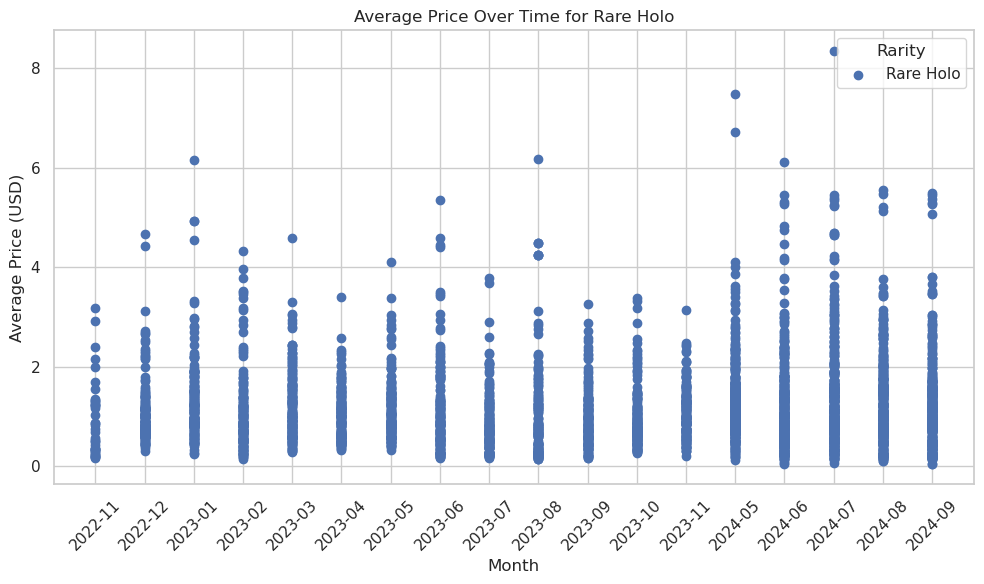

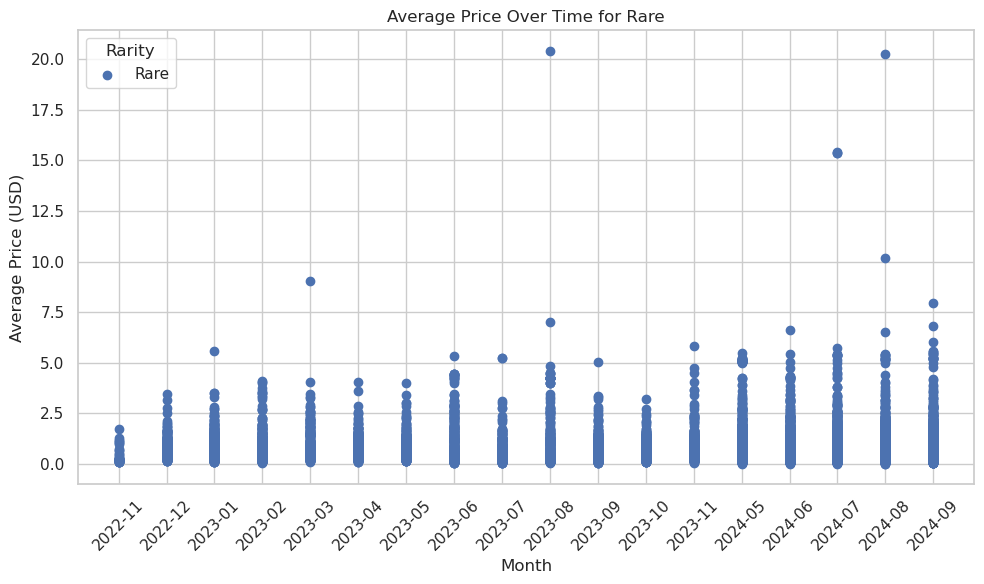

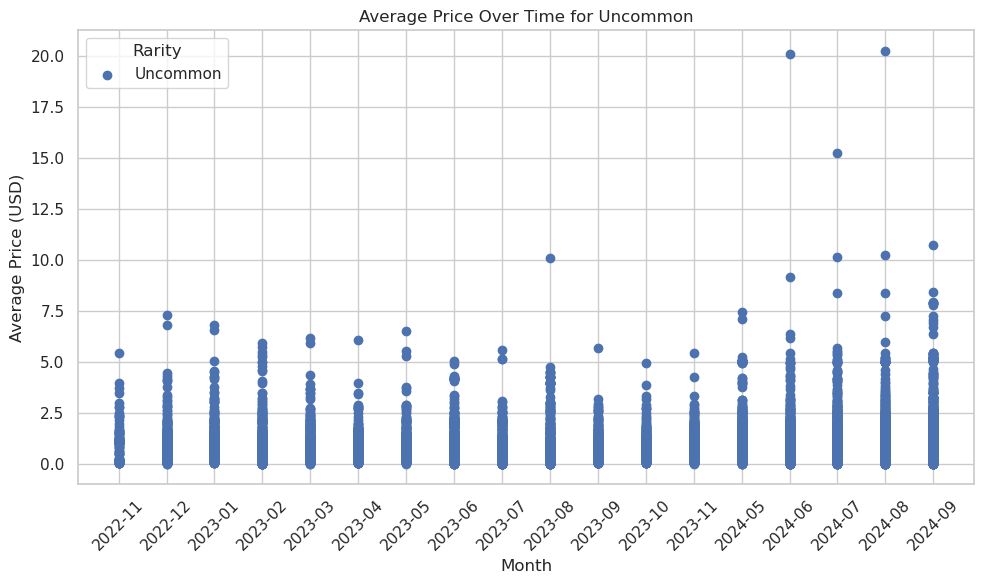

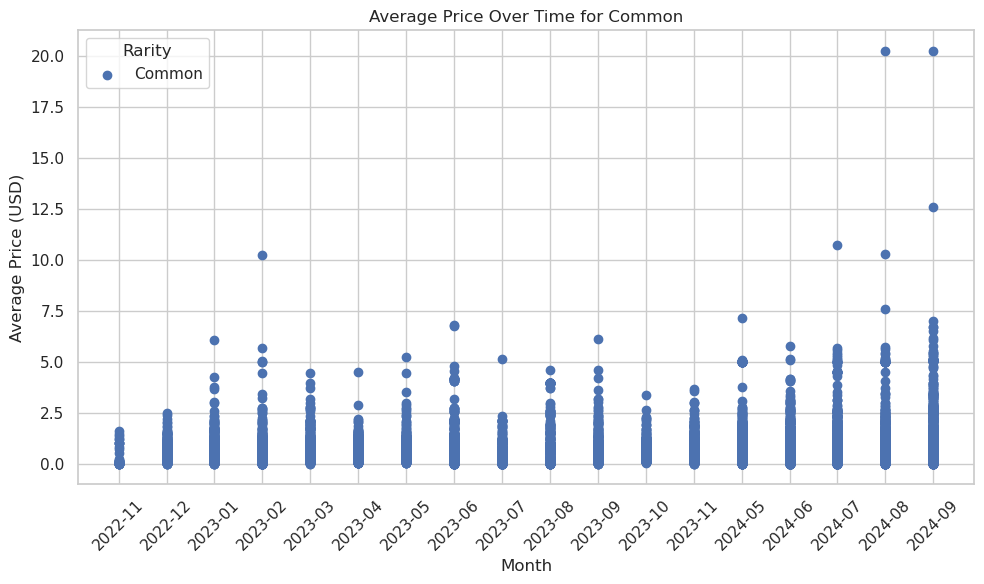

In [93]:
#Loop over each Rarity
for rarity in sorted_rarities:
    #Filter data for the current rarity
    subset = df[df['Rarity'] == rarity].sort_values(by='Month')
    
    #Create a new figure
    plt.figure(figsize=(10, 6))
    
    #Plot scatter plot
    plt.scatter(
        subset['Month'],
        subset['Average'] / 100,  # Convert cents to dollars
        label=rarity,
        marker='o'
    )
    
    #Plot
    plt.title(f'Average Price Over Time for {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Rarity')
    plt.tight_layout()
    plt.show()


# Boxplots

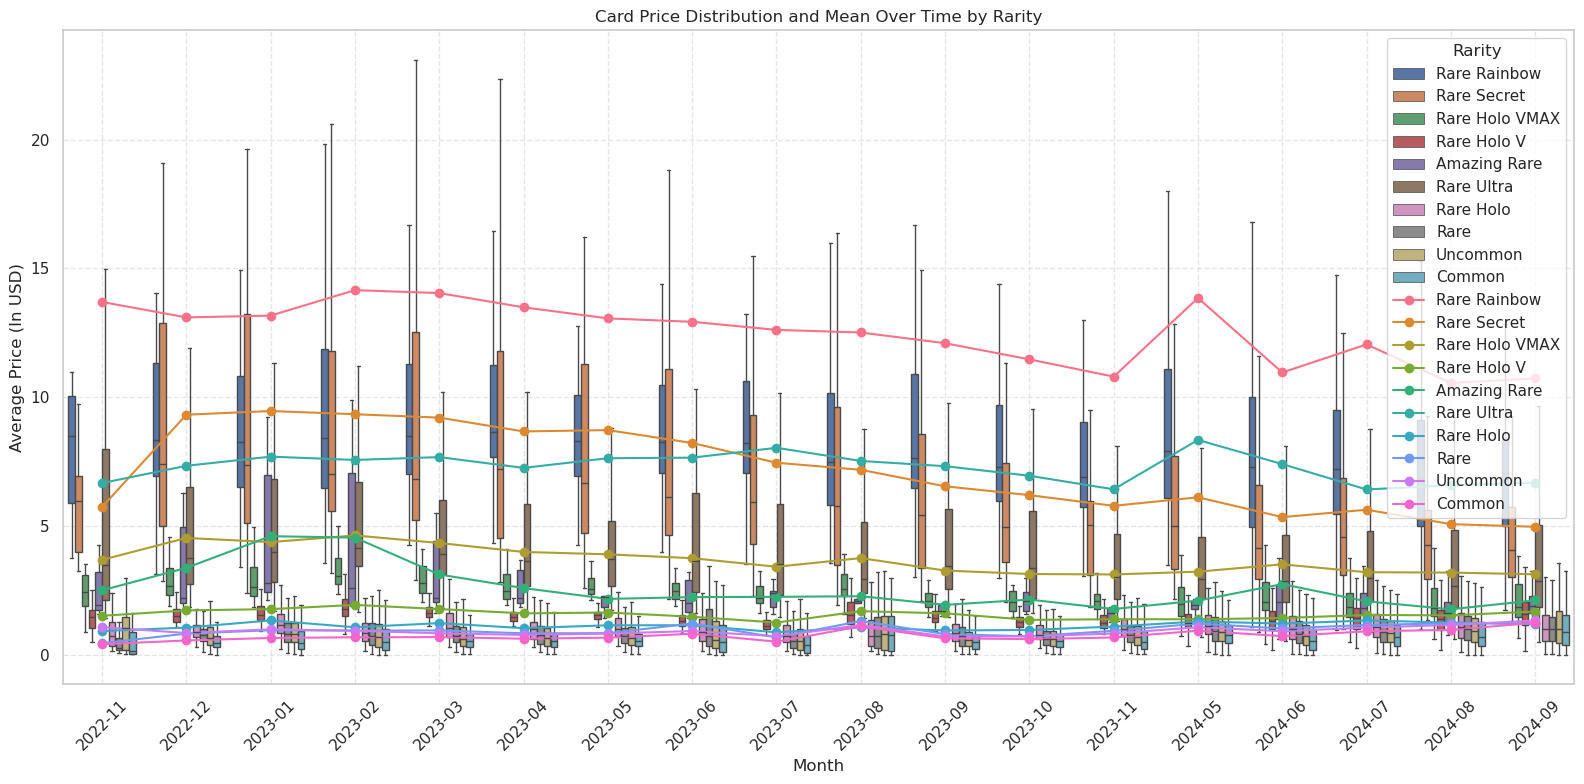

In [94]:
#Set style
sns.set(style='whitegrid')

plt.figure(figsize=(16, 8))

#Boxplot (all data combined)
sns.boxplot(
    data=df, 
    x=df['Month'] , 
    y=df['Average'] / 100, 
    hue='Rarity', 
    hue_order=sorted_rarities,
    showfliers=False,
    dodge=True, 
    linewidth=1
)

#Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

#Customize plot
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


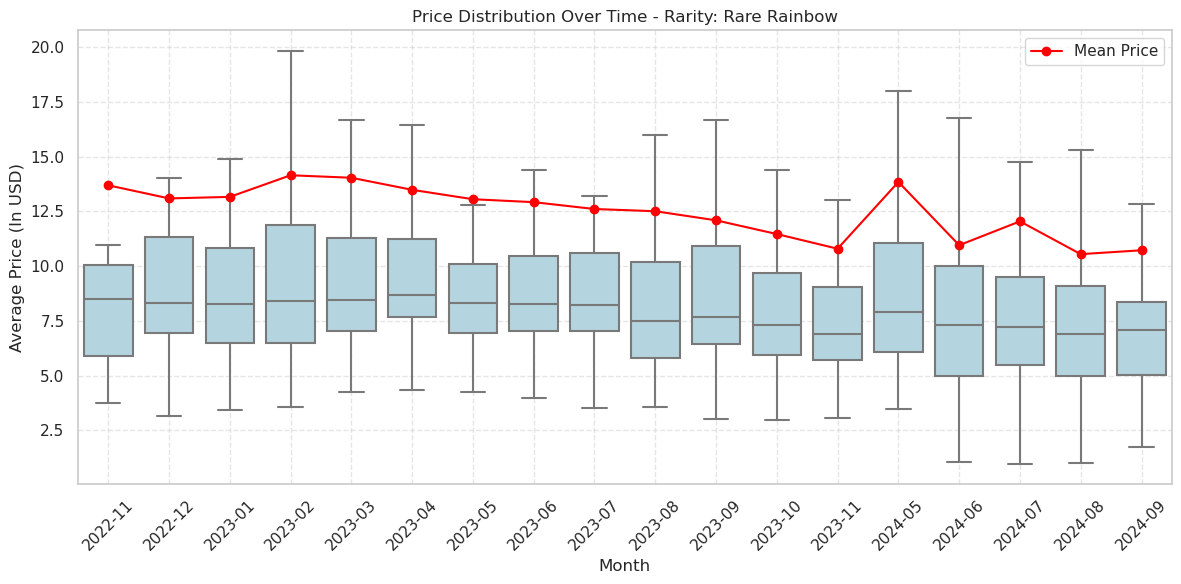

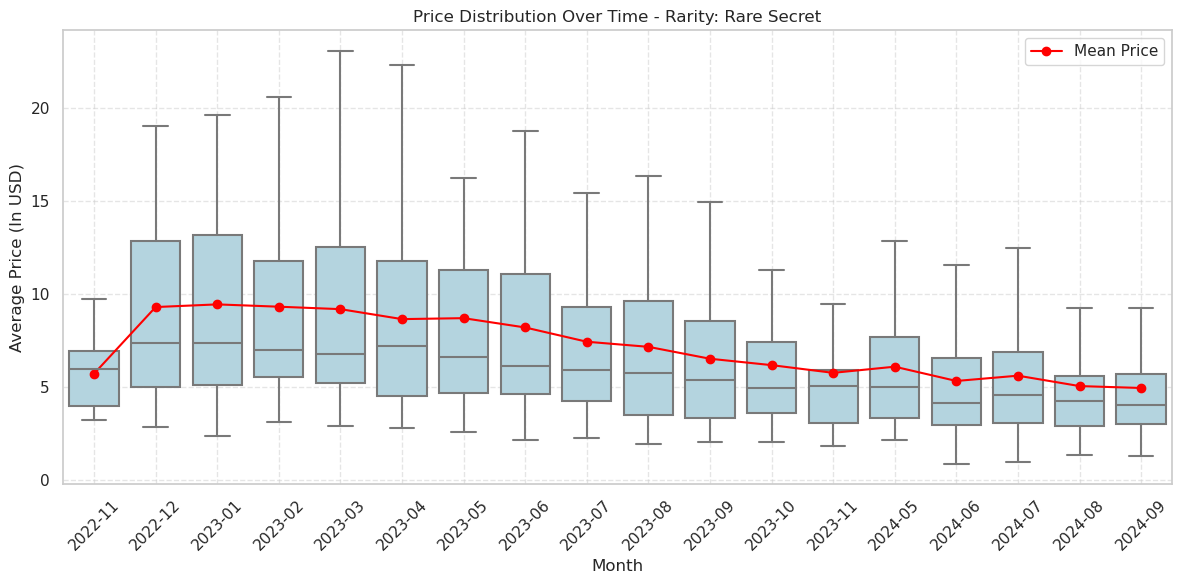

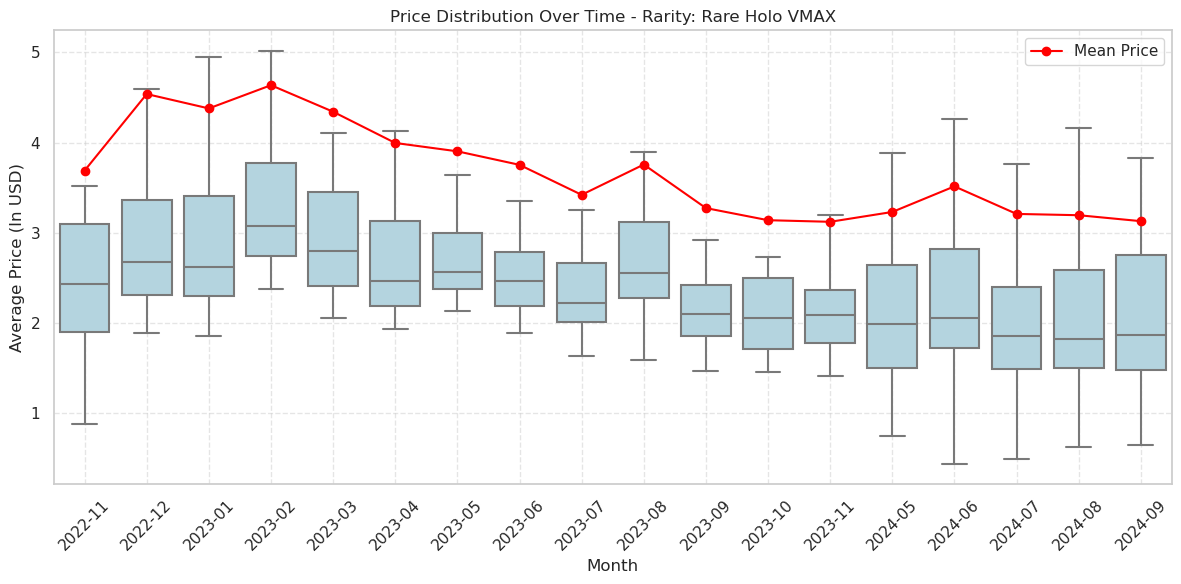

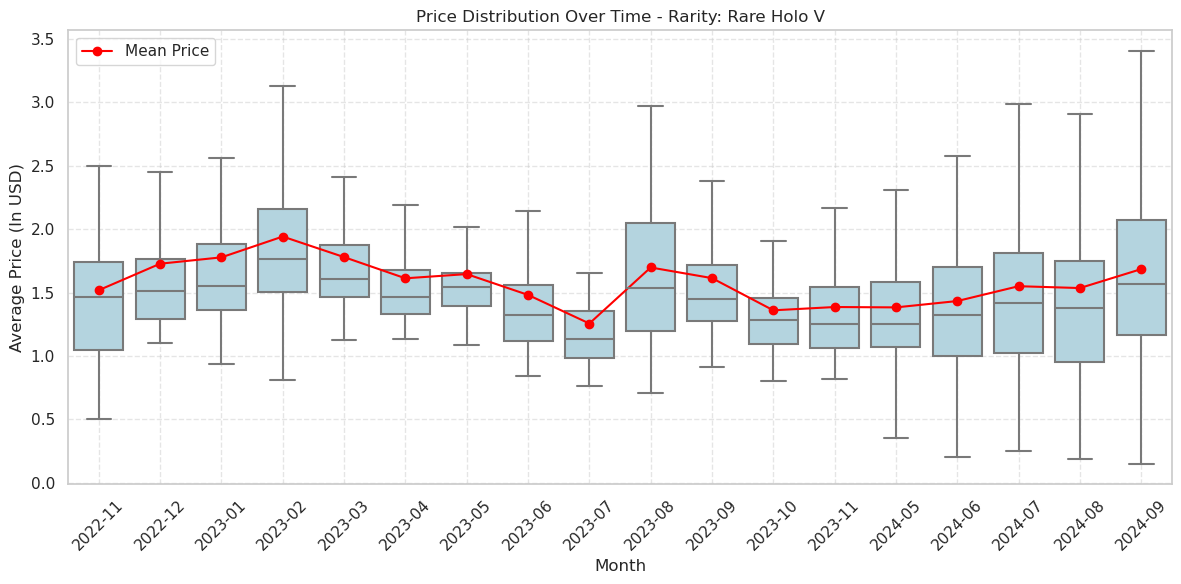

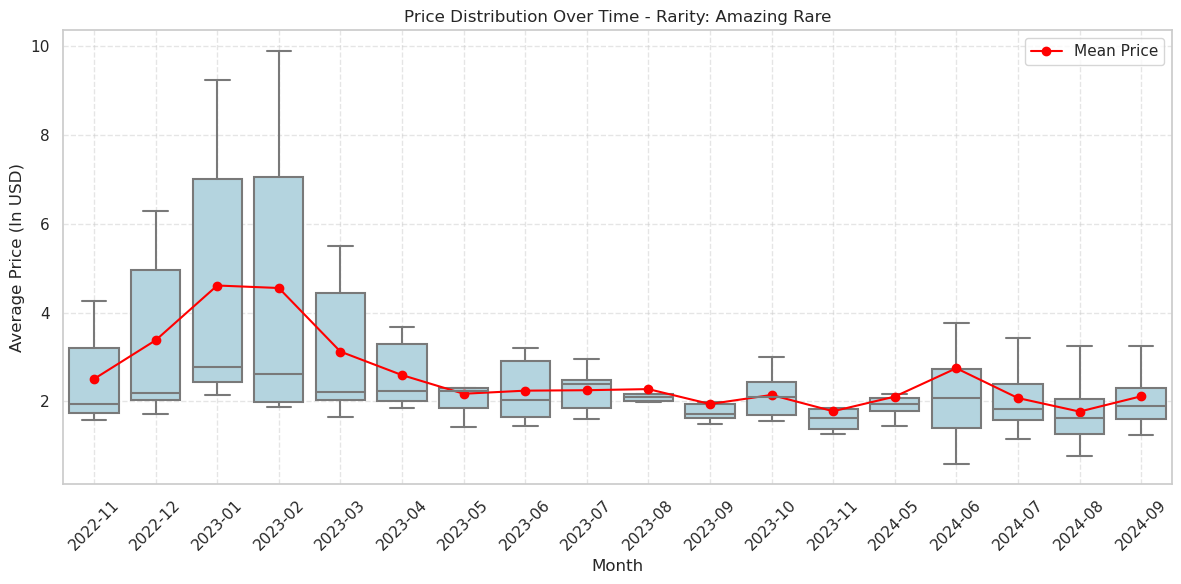

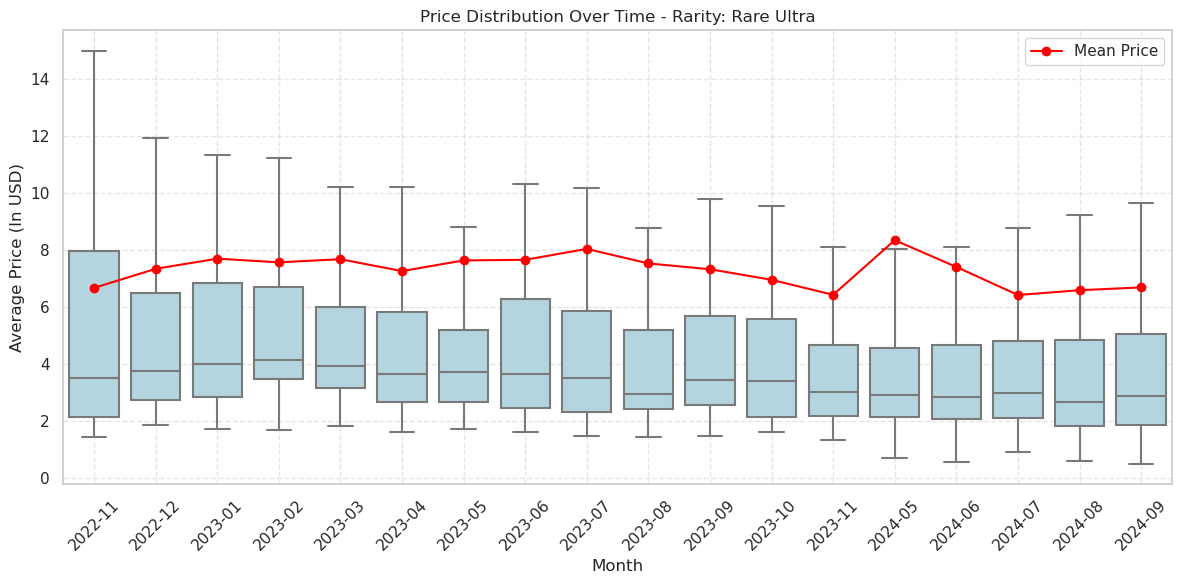

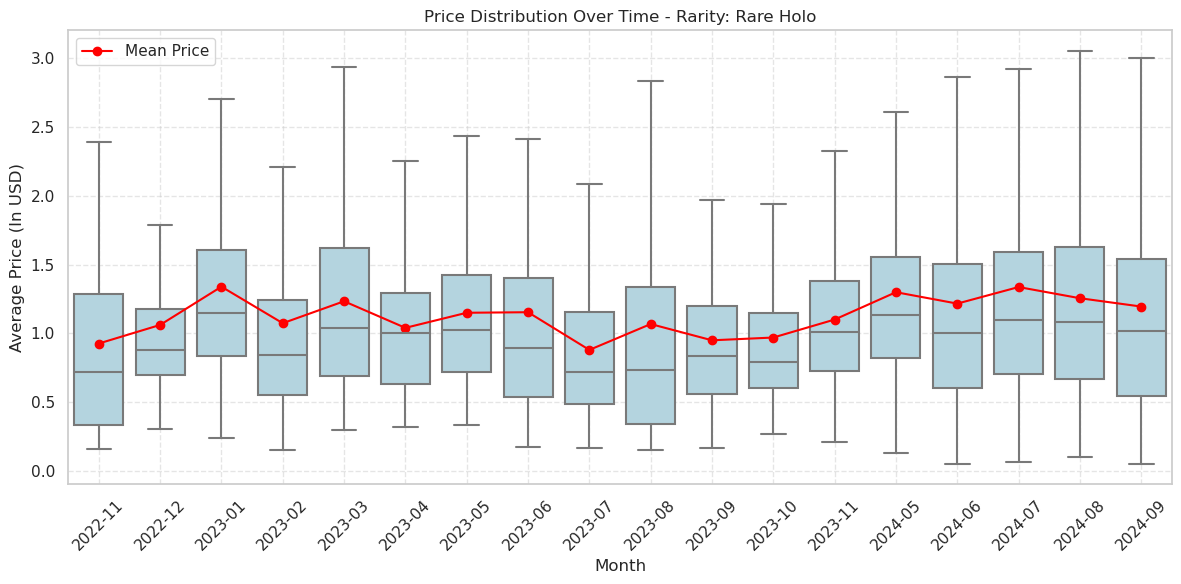

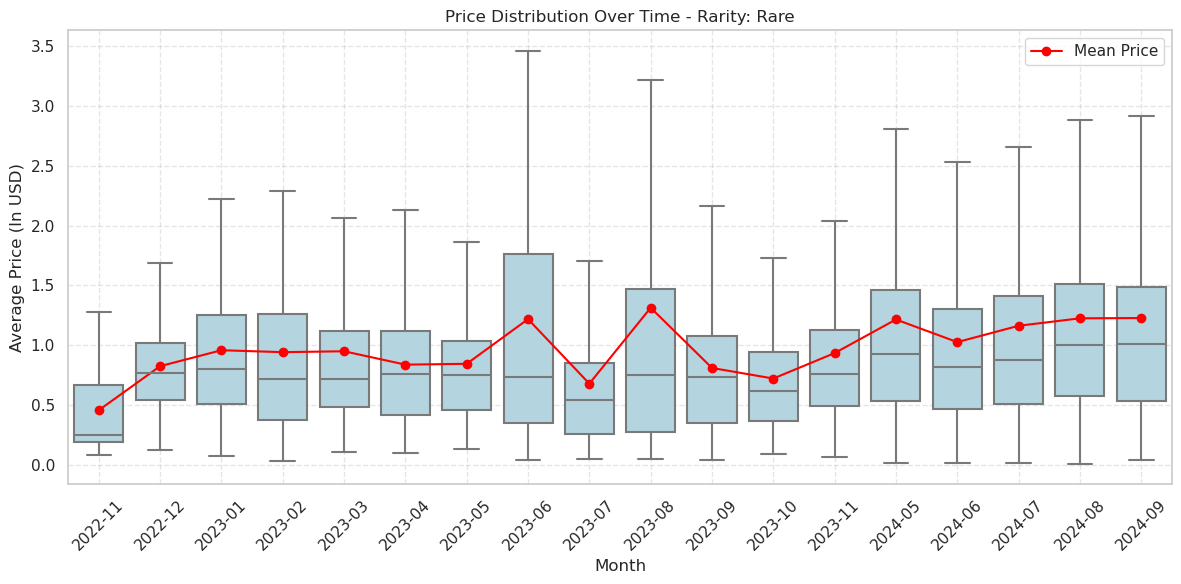

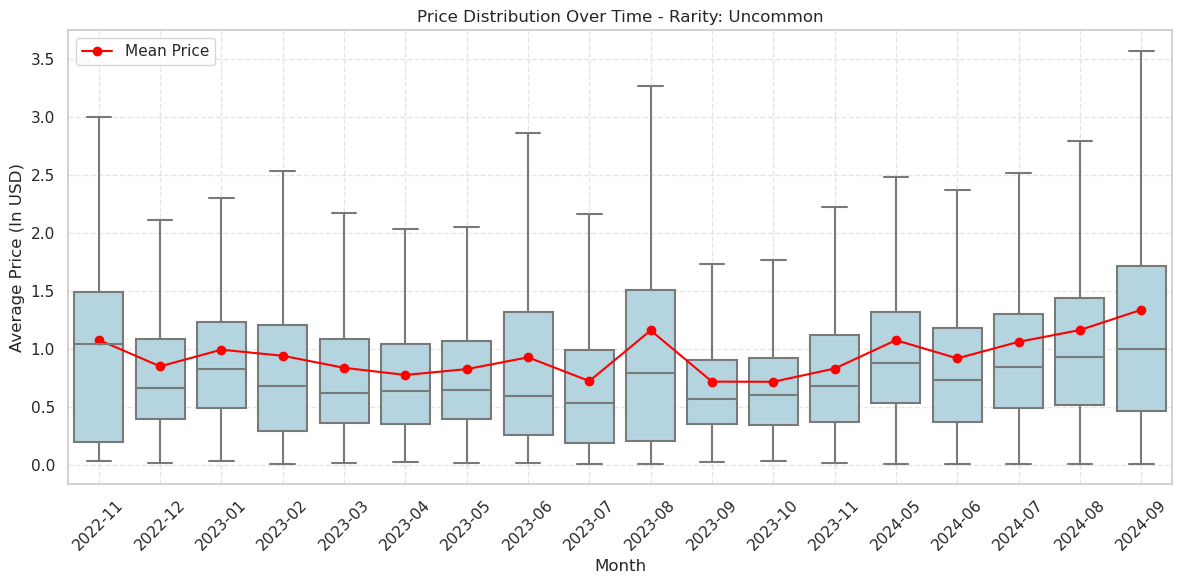

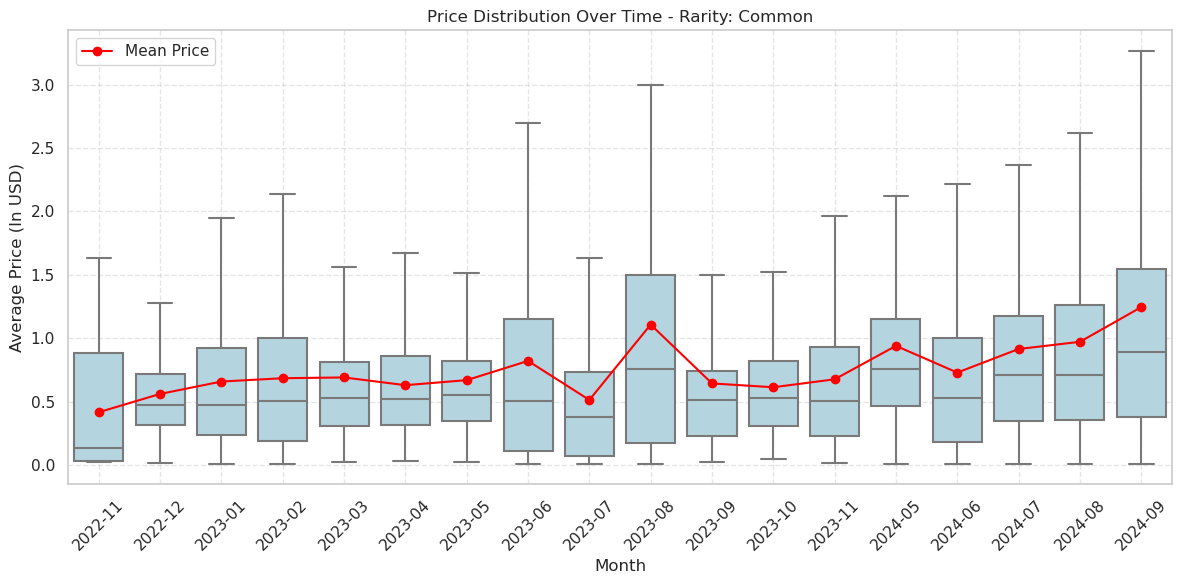

In [95]:
#Graph Style
sns.set(style='whitegrid')

#Plot for each rarity
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]

    plt.figure(figsize=(12, 6))
    
    #Boxplot of all card prices for each month
    sns.boxplot(data=subset, x=df['Month'], y=subset['Average'] / 100, color='lightblue', showfliers=False)
    
    #Line plot of mean prices per month
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, color='red', marker='o', label='Mean Price')

    #Plots
    plt.title(f'Price Distribution Over Time - Rarity: {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()


# Line graphs

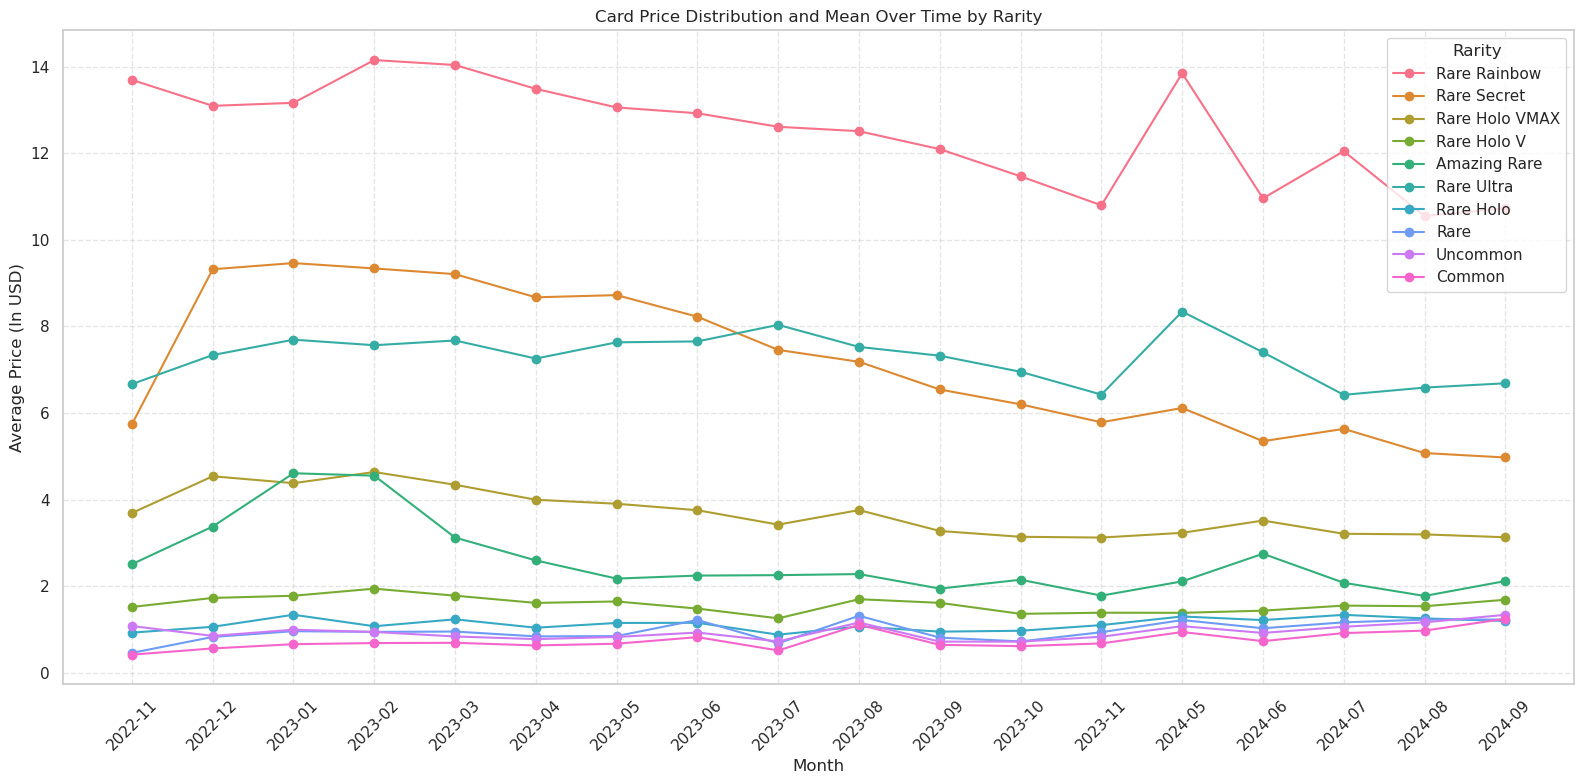

In [96]:
#Graph style
sns.set(style='whitegrid')
plt.figure(figsize=(16, 8))

#Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

#Plot Line Graphs
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


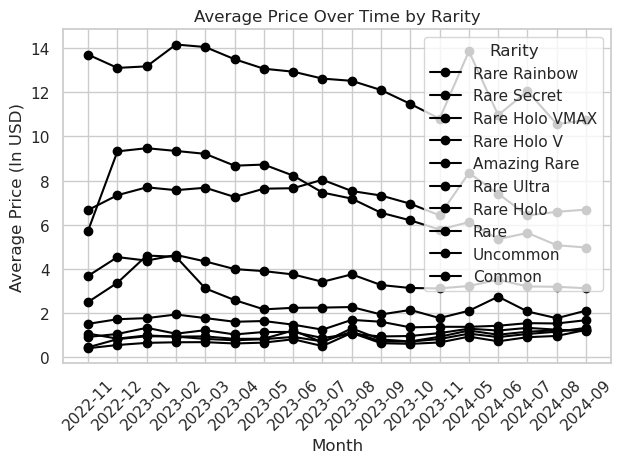

In [97]:
for rarity_df in dfs_by_rarity:
    
    #Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    
    #Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']

    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
plt.show()

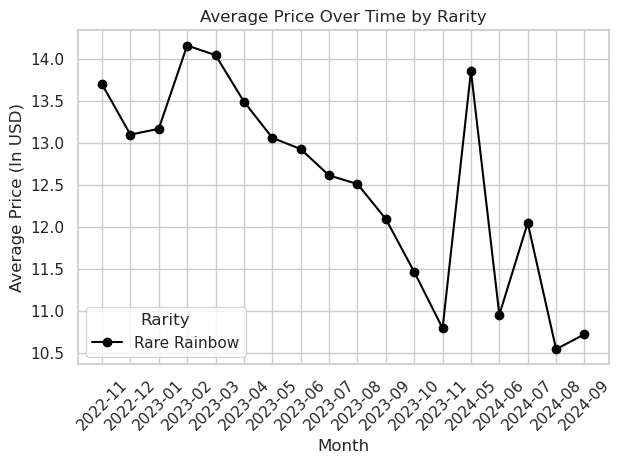

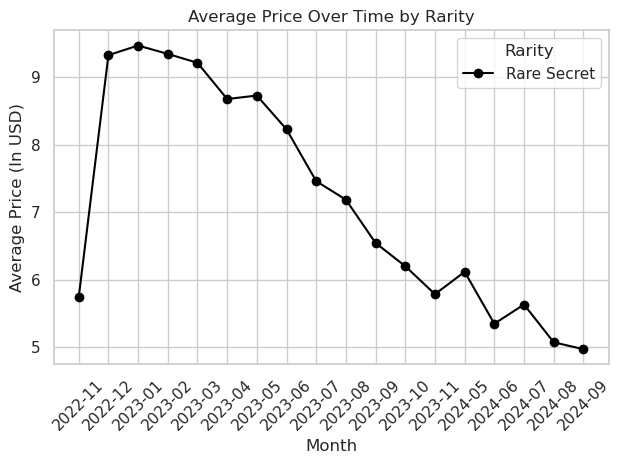

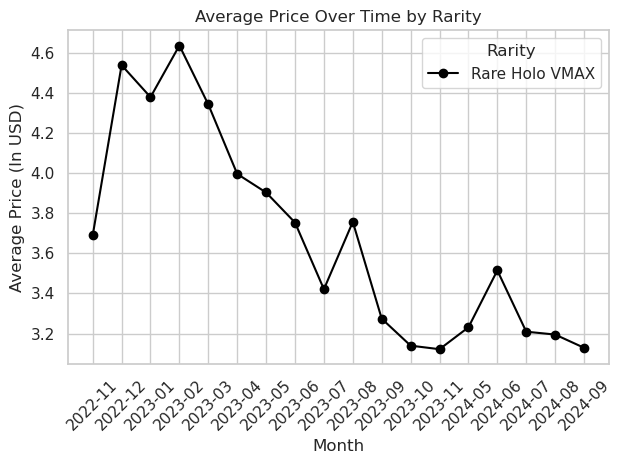

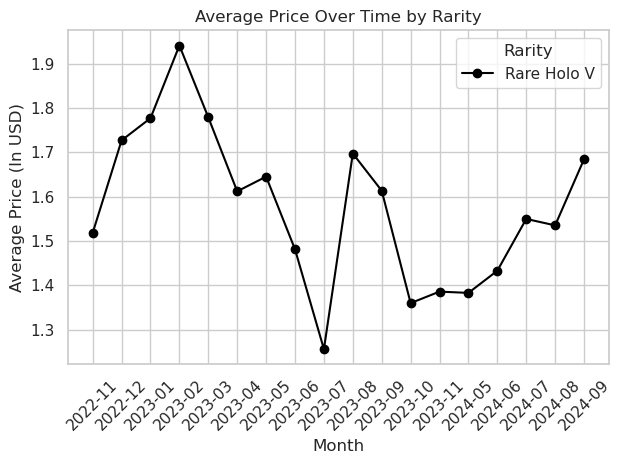

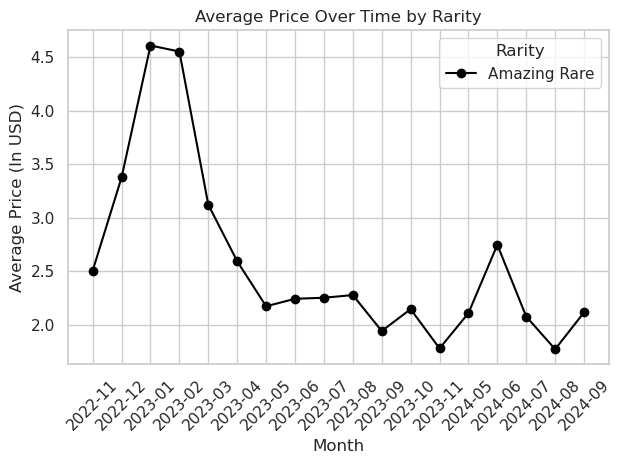

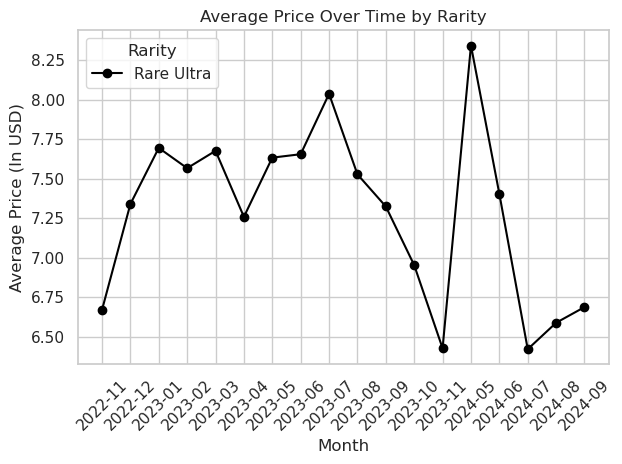

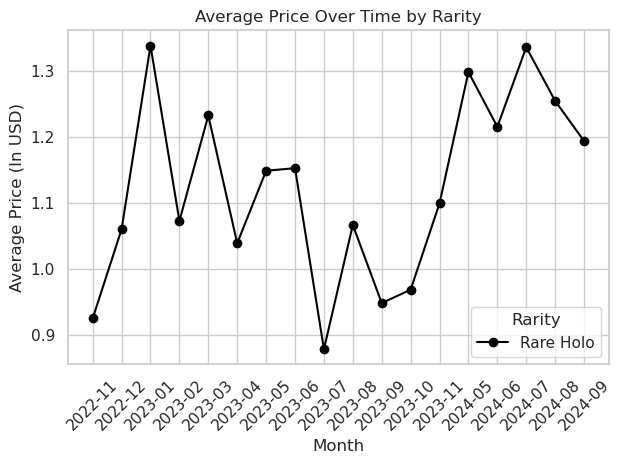

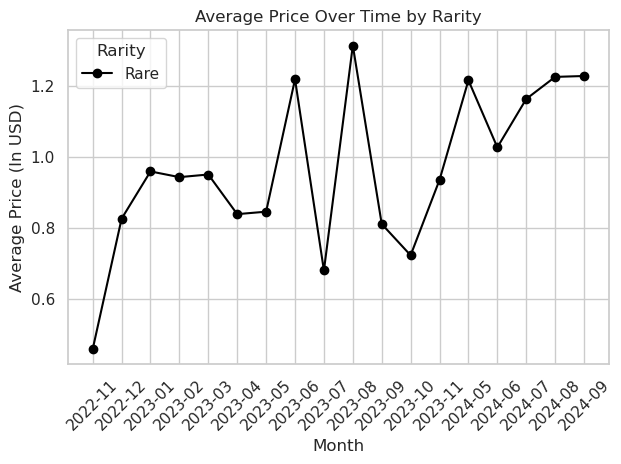

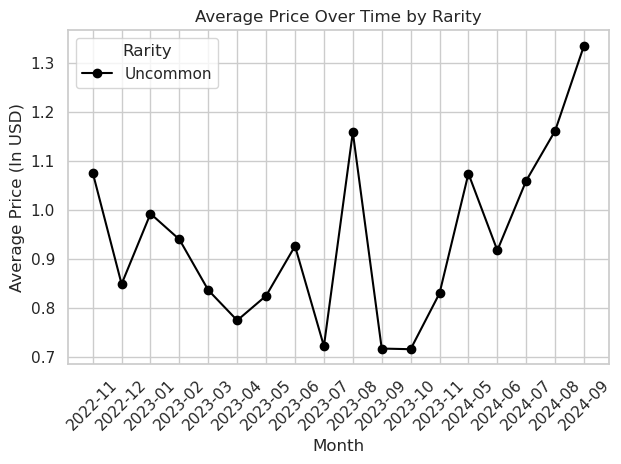

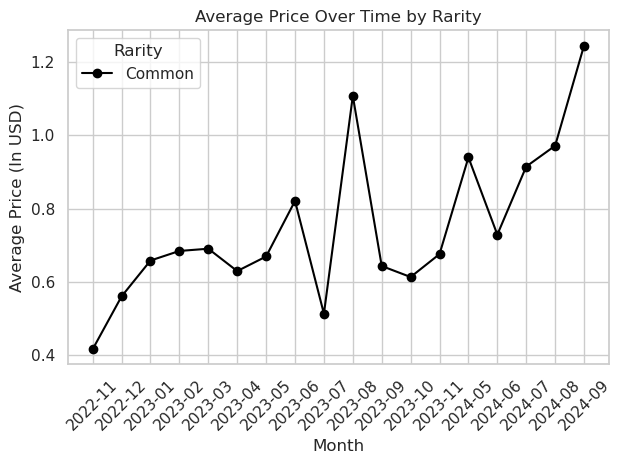

In [98]:
#Plot each rarity on its own graph for fine-grained observation.
for rarity_df in dfs_by_rarity:
    
    #Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    
    #Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    
    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create PySpark Dataframe / RDD

In [99]:
#Clean the "rarity column" by converting to a numeric encoding
df_rarity = pd.DataFrame(list(rarityOrder.items()), columns=['Rarity', 'Value'])
df_rarity_sorted = df_rarity.sort_values(by=['Value', 'Rarity']).reset_index(drop=True)
df_rarity_sorted['Rank'] = range(1, len(df_rarity_sorted) + 1)
rarity_to_rank = df_rarity_sorted.set_index('Rarity')['Rank'].to_dict()
df['rarity_rank'] = df['Rarity'].map(rarity_to_rank)

#Create the dataframe we will cluster
cluster_df = df[['rarity_rank', 'Average']].copy()

#Convert dataframe to a list of np arrays for spark context
my_tups = list(cluster_df.itertuples(index=False, name=None))
my_tups = [np.array(tup) for tup in my_tups]

# PySpark Setup

In [100]:
#Create spark context
sc = SparkContext.getOrCreate()

#Load our RDD
my_rdd = sc.parallelize(my_tups)

# Determine Optimal K-Value Using Elbow Method

In [101]:
#Detect what an appropriate k-value is
k_vals = []
for i in range(2,11):
    k_vals.append(i)

#Find error values to plot for each k-value
errors = []
for i in range(2,11):
    K = i
    model = KMeans.train(my_rdd, K, maxIterations=10, initializationMode='random')
    cluster_ids = model.predict(my_rdd)
    errors.append(model.computeCost(my_rdd))

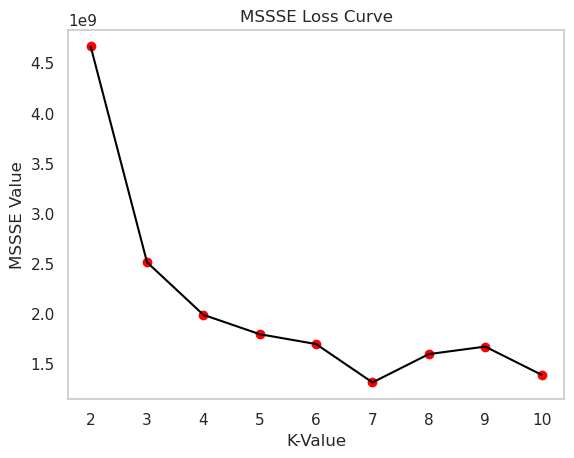

In [102]:
#Plot the WSSSE for different values of k
fig, ax = plt.subplots()
ax.plot(k_vals, errors, c='black')
ax.scatter(k_vals, errors, alpha=1, c='red')
ax.set(xlabel='K-Value',
       ylabel='MSSSE Value',
       title='MSSSE Loss Curve')
ax.grid()

# K-Means Clustering

In [103]:
#Perform clustering using the determined k-value (Usually k = 3).
K = 3
model = KMeans.train(my_rdd, K, maxIterations=10, initializationMode='random')
cluster_ids = model.predict(my_rdd)

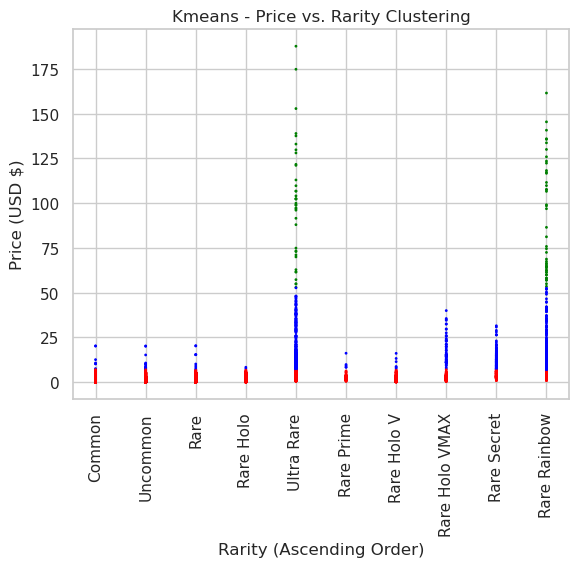

<Figure size 640x480 with 0 Axes>

In [104]:
def plot_clusters(data, cluster_ids, log):
    x_labels = ["Common", "Uncommon", "Rare", "Rare Holo", "Ultra Rare", "Rare Prime", "Rare Holo V", "Rare Holo VMAX", "Rare Secret", "Rare Rainbow"]
    
    #Replace x values with rarity labels
    replace_dict = {1:1, 2:2, 3:3, 5:4, 7:5, 10:6, 21:7, 23:8, 25:9, 31:10}
    data = np.array(data.collect())
    for i in range(0, len(data)):
        data[i][0] = replace_dict[data[i][0]]
        data[i][1] = data[i][1] / 100        
    
    #Create custom heatmap for better color visualization ... all the native ones use a difficult color to see.
    colors = ['red', 'green', 'blue']
    my_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
    
    #Define axis labels and plot title
    plt.scatter(data[:,0], data[:,1], c=cluster_ids, s=1, cmap=my_cmap)
    plt.xlabel('Rarity (Ascending Order)')
    plt.ylabel('Price (USD $)')
    plt.title('Kmeans - Price vs. Rarity Clustering')
    if(log):
        plt.yscale('log')
        plt.title('Kmeans - Price vs. Rarity Clustering (Log Scale)')
    xticks = np.unique(data[:,0])
    labels = []
    plt.xticks([1,2,3,4,5,6,7,8,9,10], labels = x_labels, rotation='vertical')
    plt.show()
    plt.clf()
    

def cluster_and_plot(data, K, log):
    #Cluster food items using kMeans and input K value
    K = K
    model = KMeans.train(data, K, maxIterations=10, initializationMode='random')

    #Cluster ID values are used to show clusters with color in plots
    cluster_ids = model.predict(data)
    
    #Plot clusters
    plot_clusters(data=data, cluster_ids=cluster_ids.collect(), log=log)

#Three clusters -> low, mid, high prices.
cluster_and_plot(data=my_rdd, K=3, log=False)



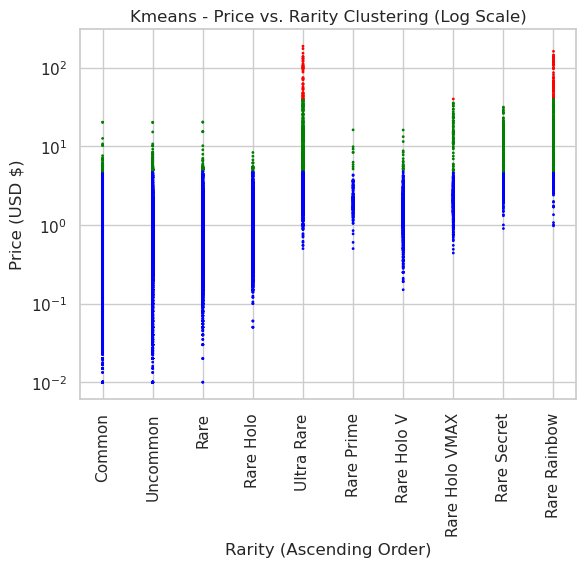

<Figure size 640x480 with 0 Axes>

In [105]:
#Plotting log scale for clearer data.
cluster_and_plot(data=my_rdd, K=3, log=True)

# Outlier Investigation

In [106]:
#Lets pull the top 5 most expensive cards at each rarity!
#Create our data structure to hold df entries.
rarity_labels = ["Common", 
                 "Uncommon", 
                 "Rare", 
                 "Rare Holo", 
                 "Rare Ultra", 
                 "Rare Prime", 
                 "Rare Holo V", 
                 "Rare Holo VMAX", 
                 "Rare Secret", 
                 "Rare Rainbow"]

expensive_outlier_prices_by_rarity = []

#Find our top x=5 prices for each rarity
for rarity in rarity_labels:
    filtered_df = df[df['Rarity'] == rarity].sort_values(by="Average", ascending=False)
    expensive_outlier_prices_by_rarity.append(filtered_df.head(5))
    
#Create a list of the top x=5 most expensive cards of each rarity.
expensive_df = pd.concat(expensive_outlier_prices_by_rarity).drop_duplicates(keep='first', subset=['Name'])
print(expensive_df.sort_values(by='Average', ascending=False).head(20))

      Set ID  Number                       Name          Rarity  \
34444  swsh5     155                Tyranitar V      Rare Ultra   
28024  swsh4     188               Pikachu VMAX    Rare Rainbow   
20665  swsh3      20             Charizard VMAX  Rare Holo VMAX   
35176  swsh5     181                 Level Ball     Rare Secret   
4981   swsh1     216                 Quick Ball     Rare Secret   
10380  swsh2     141                    Snorlax            Rare   
35658  swsh5      28                   Salazzle            Rare   
32090  swsh5       1                 Bellsprout          Common   
33095  swsh5     121                      Bruno        Uncommon   
24938  swsh4     112            Galarian Meowth          Common   
11354  swsh2     162                     Nugget        Uncommon   
17203  swsh3     116                Eternatus V     Rare Holo V   
10369  swsh2     140                  Zamazenta            Rare   
10282  swsh2     139                     Zacian            Rar

In [ ]:
#Cross reference our list of metadecks with the current cards and see if we get matches.
meta_list = pd.read_csv("Metadecks/filtered_cards.csv")
meta_list.head()
meta_cards = meta_list['Card Name'].tolist()
df = df.sort_values(by='Average', ascending=False)

#Iterate through our dataframe looking for matches and
#append the location in the master dataframe.
card_index = []
for index,row in df.iterrows():
    for j in range(0, len(meta_cards)):
        if(row['Name'] == meta_cards[j]):
            card_index.append(index)

#This shows us a sorted list of meta cards and where they rank by value in our dataset.
#ultimately, we did not find that the meta deck inclusion affected the card prices in 
#a meaningful way.
print('Average price: ', df['Average'].mean())
print(df.iloc[1227])

#Remove duplicates by casting as a set then sort.  
#Print only the first 20 entries.
print(sorted(list(set((card_index))))[0:20])

Average price:  188.4942563666363
Set ID              swsh2
Number                179
Name            Milotic V
Rarity         Rare Ultra
Grade           holo-good
Month             2023-11
Average            809.44
rarity_rank             7
Name: 12074, dtype: object
[780, 781, 782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799]
